# TurboQuant: A Visual & Mathematical Walkthrough

This notebook breaks down the TurboQuant algorithm step by step, with visuals and code.

**Prerequisites**: Basic linear algebra (vectors, dot products, matrices) and basic probability (mean, variance).

---

## What Problem Does TurboQuant Solve?

Imagine you have millions of high-dimensional vectors (e.g., 1536 numbers each) stored in a database.  
Each number is a 32-bit float → **tons of memory**.

**Goal**: Replace each 32-bit float with just 2-4 bits, while keeping the vectors "close enough" to the originals.

This is called **vector quantization**.

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist
from scipy.stats import norm

np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

---
## Step 0: What is Quantization?

Quantization = rounding a continuous value to one of a few allowed values (called **centroids** or **codewords**).

**Example**: If your allowed values are `{-0.5, 0.0, 0.5}`, then:
- `0.37` → `0.5`
- `-0.21` → `0.0`  
- `-0.68` → `-0.5`

With 3 values you only need ~1.58 bits per number (since $\lceil\log_2 3\rceil = 2$).  
With $2^b$ values you need exactly $b$ bits per number.

The **error** is how far the rounded value is from the original:

$$\text{MSE} = \mathbb{E}\left[\|\mathbf{x} - \tilde{\mathbf{x}}\|^2\right]$$

where $\mathbf{x}$ is the original and $\tilde{\mathbf{x}}$ is the reconstructed (quantized) vector.

Original:  [ 0.37 -0.21 -0.68  0.12  0.85 -0.44]
Quantized: [ 0.5  0.  -0.5  0.   0.5 -0.5]


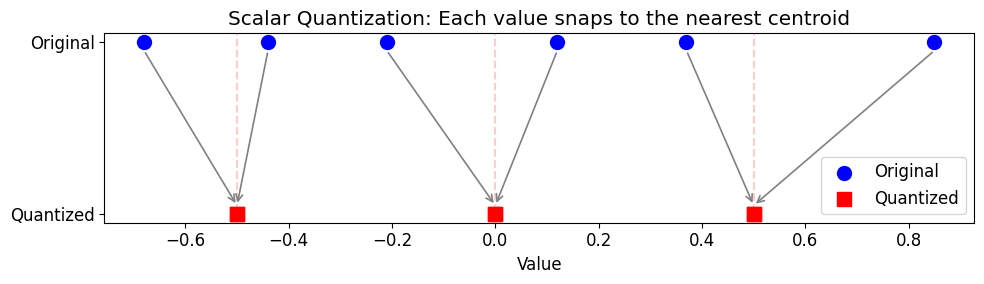

Original:  [ 0.37 -0.21 -0.68  0.12  0.85 -0.44]
Quantized: [ 0.5  0.  -0.5  0.   0.5 -0.5]
MSE:       0.0390


In [52]:
# Simple 1D quantization demo
original_values = np.array([0.37, -0.21, -0.68, 0.12, 0.85, -0.44])
centroids = np.array([-0.5, 0.0, 0.5])

# Quantize: find nearest centroid for each value
indices = np.array([np.argmin(np.abs(v - centroids)) for v in original_values])
quantized = centroids[indices]
print(f"Original:  {original_values}")
print(f"Quantized: {quantized}")

fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.scatter(original_values, np.ones_like(original_values), c='blue', s=100, zorder=3, label='Original')
ax.scatter(quantized, np.zeros_like(quantized), c='red', s=100, marker='s', zorder=3, label='Quantized')
for o, q in zip(original_values, quantized):
    ax.annotate('', xy=(q, 0.05), xytext=(o, 0.95),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))
for c in centroids:
    ax.axvline(c, color='red', alpha=0.2, linestyle='--')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Quantized', 'Original'])
ax.set_xlabel('Value')
ax.set_title('Scalar Quantization: Each value snaps to the nearest centroid')
ax.legend()
plt.tight_layout()
plt.show()

mse = np.mean((original_values - quantized)**2)
print(f"Original:  {original_values}")
print(f"Quantized: {quantized}")
print(f"MSE:       {mse:.4f}")

---
## Step 1: The Key Problem — We Don't Know the Distribution

To pick **optimal centroids**, you need to know the **distribution** of your data.  
But real-world vectors have arbitrary, unknown distributions with outliers.

Traditional approaches (like Product Quantization) run **k-means** on the actual data to learn centroids.  
This is slow and requires seeing all the data upfront.

### TurboQuant's Big Idea

> **Don't adapt to the data. Instead, transform the data into a known distribution, then use pre-computed optimal centroids.**

How? **Random rotation.**

---
## Step 2: Random Rotation — The Magic Trick

### What is a rotation matrix?

A **rotation matrix** $\mathbf{\Pi}$ is a square matrix that:
- Preserves lengths: $\|\mathbf{\Pi x}\| = \|\mathbf{x}\|$
- Preserves angles/dot products: $\langle \mathbf{\Pi x}, \mathbf{\Pi y} \rangle = \langle \mathbf{x}, \mathbf{y} \rangle$
- Is orthogonal: $\mathbf{\Pi}^\top \mathbf{\Pi} = \mathbf{I}$ (identity)

Think of it like spinning an object — its shape doesn't change, just its orientation.

### Why rotate?

Any unit vector $\mathbf{x}$ (on the unit sphere) when multiplied by a **random** rotation $\mathbf{\Pi}$,  
becomes a **uniformly random point on the unit sphere**.

$$\mathbf{y} = \mathbf{\Pi} \cdot \mathbf{x}$$

This is true **regardless** of what $\mathbf{x}$ was! The rotation "scrambles" any structure  
into a universal, predictable distribution.

---

### Concrete Example: The Dice Analogy

Imagine you have a **loaded die** — it always lands on 6. The distribution is: `{6: 100%, rest: 0%}`.  
Now someone shakes the die inside a black box before rolling it. The shaking is like a **random rotation** —  
it doesn't change the die's shape, but now the outcome is **uniformly random**: `{1–6: ~16.7% each}`.

The same thing happens with vectors:

| | Before rotation | After rotation |
|---|---|---|
| **Vector** | $\mathbf{x} = [1, 0, 0, \ldots, 0]$ (all weight in dim 1) | $\mathbf{y} = \mathbf{\Pi x}$ (weight spread evenly) |
| **Coordinates** | One big, rest zero | All small, roughly equal magnitude |
| **Distribution** | Completely unpredictable | Always the same (Beta → Gaussian) |

**Analogy**: Think of 3 friends standing in a room:
- **Before rotation**: All 3 are crammed in the corner (structured, hard to describe with a simple rule)
- **After rotation**: They're spread randomly around the room (uniform, easy to describe statistically)

BEFORE rotation — the vector is very 'structured':
  x = [1. 0. 0. 0. 0. 0. 0. 0.]
  Length = 1.0
  All weight in dimension 0, rest are zero

After random rotation #1:
  y = [-0.541, -0.326, -0.177, +0.015, +0.528, -0.269, -0.086, +0.459]
  Length = 1.0000  (preserved! same as before)

After random rotation #2:
  y = [-0.124, +0.035, +0.212, +0.495, +0.732, +0.157, +0.342, -0.126]
  Length = 1.0000  (preserved! same as before)

After random rotation #3:
  y = [-0.412, -0.038, +0.532, +0.083, +0.397, +0.458, -0.411, -0.050]
  Length = 1.0000  (preserved! same as before)


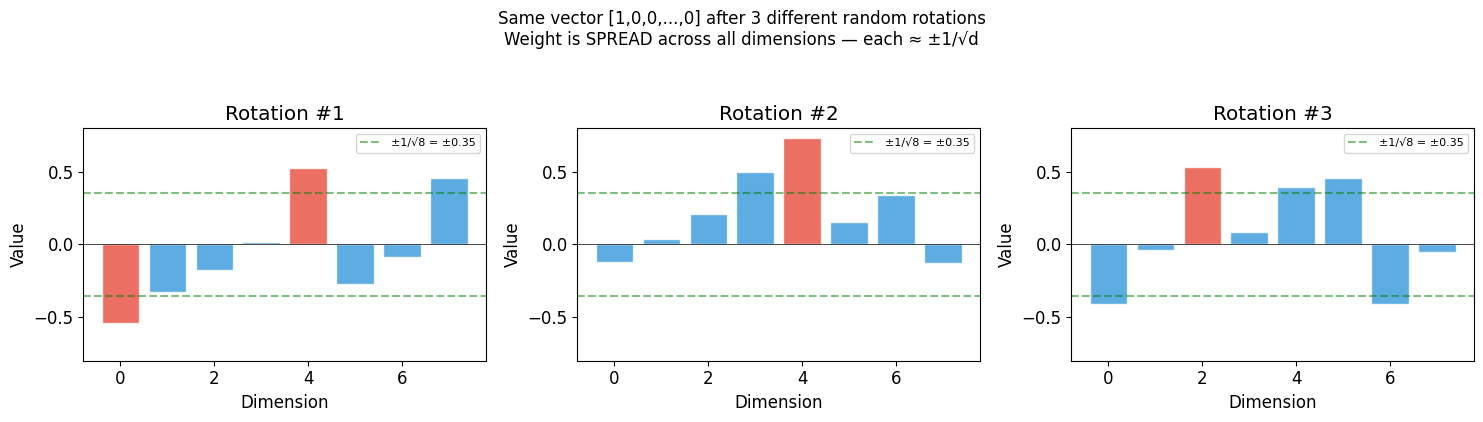


KEY INSIGHT:
  Before: 1 big coordinate (1.0), 7 zeros
  After:  All ~8 coordinates are roughly ±0.354
  The LENGTH is preserved (1.0), but the SHAPE is scrambled!
  Different rotations give different values,
  but the STATISTICAL PATTERN is always the same.


In [53]:
# CONCRETE EXAMPLE: A single vector before and after random rotation

# Our "loaded die" vector — ALL weight in dimension 0
d = 8
x = np.zeros(d)
x[0] = 1.0  # the vector [1, 0, 0, 0, 0, 0, 0, 0]

print("=" * 60)
print("BEFORE rotation — the vector is very 'structured':")
print(f"  x = {x}")
print(f"  Length = {np.linalg.norm(x):.1f}")
print(f"  All weight in dimension 0, rest are zero")
print("=" * 60)

# Apply 3 different random rotations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
np.random.seed(7)

for i in range(3):
    G = np.random.randn(d, d)
    Pi, _ = np.linalg.qr(G)      # random rotation matrix
    y = Pi @ x                     # rotate the vector
    
    print(f"\nAfter random rotation #{i+1}:")
    print(f"  y = [{', '.join(f'{v:+.3f}' for v in y)}]")
    print(f"  Length = {np.linalg.norm(y):.4f}  (preserved! same as before)")
    
    # Plot
    ax = axes[i]
    colors = ['#e74c3c' if abs(v) > 0.5 else '#3498db' for v in y]
    bars = ax.bar(range(d), y, color=colors, edgecolor='white', alpha=0.8)
    ax.axhline(0, color='k', lw=0.5)
    ax.axhline(1/np.sqrt(d), color='green', lw=1.5, ls='--', alpha=0.5, label=f'±1/√{d} = ±{1/np.sqrt(d):.2f}')
    ax.axhline(-1/np.sqrt(d), color='green', lw=1.5, ls='--', alpha=0.5)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Value')
    ax.set_title(f'Rotation #{i+1}')
    ax.legend(fontsize=8)

plt.suptitle('Same vector [1,0,0,...,0] after 3 different random rotations\n'
             'Weight is SPREAD across all dimensions — each ≈ ±1/√d',
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("KEY INSIGHT:")
print(f"  Before: 1 big coordinate (1.0), {d-1} zeros")
print(f"  After:  All ~{d} coordinates are roughly ±{1/np.sqrt(d):.3f}")
print(f"  The LENGTH is preserved ({np.linalg.norm(x):.1f}), but the SHAPE is scrambled!")
print(f"  Different rotations give different values,")
print(f"  but the STATISTICAL PATTERN is always the same.")
print("=" * 60)

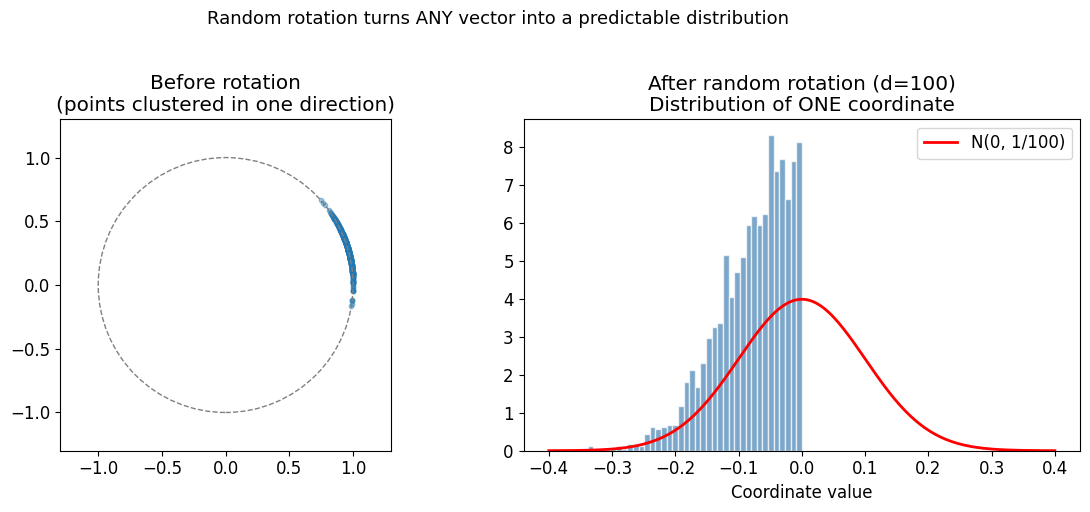

In [54]:
# Demo: Random rotation in 2D
# Start with a "structured" set of points (all near one direction)
n_points = 500
angles_orig = np.random.normal(loc=0.3, scale=0.15, size=n_points)  # clustered around 0.3 rad
points_orig = np.column_stack([np.cos(angles_orig), np.sin(angles_orig)])

# Generate a random 2D rotation
theta = np.random.uniform(0, 2 * np.pi)
Pi = np.array([[np.cos(theta), -np.sin(theta)],
               [np.sin(theta),  np.cos(theta)]])

# But in high-d, random rotation makes points UNIFORM on the sphere
# Let's show the effect on coordinates in higher dimensions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 2D visualization: before and after
axes[0].scatter(points_orig[:, 0], points_orig[:, 1], alpha=0.4, s=10)
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
axes[0].add_patch(circle)
axes[0].set_aspect('equal')
axes[0].set_title('Before rotation\n(points clustered in one direction)')
axes[0].set_xlim(-1.3, 1.3)
axes[0].set_ylim(-1.3, 1.3)

# In high-d, uniform on sphere. Let's show d=100
d = 100
x_structured = np.zeros(d)
x_structured[0] = 1.0  # a very "structured" vector: all weight in dim 0

n_rotations = 2000
first_coords = []
for _ in range(n_rotations):
    # Random rotation via QR decomposition of random Gaussian matrix
    G = np.random.randn(d, d)
    Pi_hd, _ = np.linalg.qr(G)
    y = Pi_hd @ x_structured
    first_coords.append(y[0])

axes[1].hist(first_coords, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
# Overlay the theoretical Beta distribution (≈ Gaussian for large d)
xx = np.linspace(-0.4, 0.4, 200)
axes[1].plot(xx, norm.pdf(xx, 0, 1/np.sqrt(d)), 'r-', lw=2, label=f'N(0, 1/{d})')
axes[1].set_title(f'After random rotation (d={d})\nDistribution of ONE coordinate')
axes[1].set_xlabel('Coordinate value')
axes[1].legend()

plt.suptitle('Random rotation turns ANY vector into a predictable distribution', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 3: The Beta Distribution — What Each Coordinate Looks Like

After random rotation, each coordinate of $\mathbf{y} = \mathbf{\Pi x}$ follows a **Beta distribution**:

$$f_X(x) = \frac{\Gamma(d/2)}{\sqrt{\pi} \cdot \Gamma((d-1)/2)} \cdot (1 - x^2)^{(d-3)/2}, \quad x \in [-1, 1]$$

Don't worry about the formula — here's what matters:

| Dimension $d$ | Shape | Looks like |
|---|---|---|
| Small (d=3) | Wide, flat-ish | Uniform-ish |
| Medium (d=50) | Bell-shaped | Narrow Gaussian |
| Large (d=1536) | Very tight spike | Very narrow Gaussian $\mathcal{N}(0, 1/d)$ |

**Key insight**: In high dimensions, this converges to $\mathcal{N}(0, 1/d)$ — a Gaussian with tiny variance.  
The values are **tightly concentrated** near zero, making quantization very efficient.

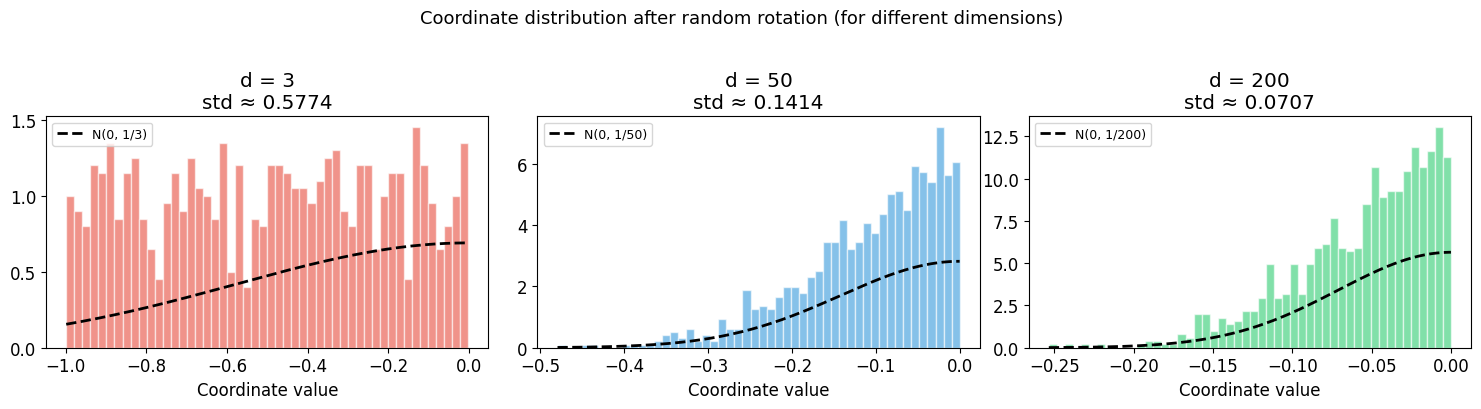

In [55]:
# Visualize the Beta distribution for different dimensions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

dimensions = [3, 50, 200]
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, d, color in zip(axes, dimensions, colors):
    # Generate random rotations of e_1 and collect first coordinate
    coords = []
    for _ in range(1000):
        G = np.random.randn(d, d)
        Pi, _ = np.linalg.qr(G)
        e1 = np.zeros(d)
        e1[0] = 1.0
        y = Pi @ e1
        coords.append(y[0])
    coords = np.array(coords)
    
    ax.hist(coords, bins=50, density=True, alpha=0.6, color=color, edgecolor='white')
    
    # Overlay Gaussian approximation
    xx = np.linspace(coords.min(), coords.max(), 200)
    ax.plot(xx, norm.pdf(xx, 0, 1/np.sqrt(d)), 'k--', lw=2, label=f'N(0, 1/{d})')
    
    ax.set_title(f'd = {d}\nstd ≈ {1/np.sqrt(d):.4f}')
    ax.set_xlabel('Coordinate value')
    ax.legend(fontsize=9)

plt.suptitle('Coordinate distribution after random rotation (for different dimensions)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 4: Optimal Scalar Quantization (Lloyd-Max)

Now that we **know** the distribution of each coordinate, we can compute the **best possible centroids**  
for any given number of bits.

This is a classic problem called **Lloyd-Max quantization** (1960s!):

Given a probability distribution $f(x)$ and $k = 2^b$ centroids, find centroids $c_1, c_2, \ldots, c_k$ that minimize:

$$\text{Cost} = \sum_{i=1}^{k} \int_{\text{boundary}_i} |x - c_i|^2 \cdot f(x) \, dx$$

The algorithm alternates two steps:
1. **Assign** each point to its nearest centroid (Voronoi boundaries = midpoints)
2. **Update** each centroid to the conditional mean of its region

This is just **1D k-means** on a continuous distribution.

### The beautiful part
Since the distribution is **always the same** (it only depends on dimension $d$ and bit-width $b$),  
we compute these centroids **once** and reuse them forever. Zero cost at runtime!

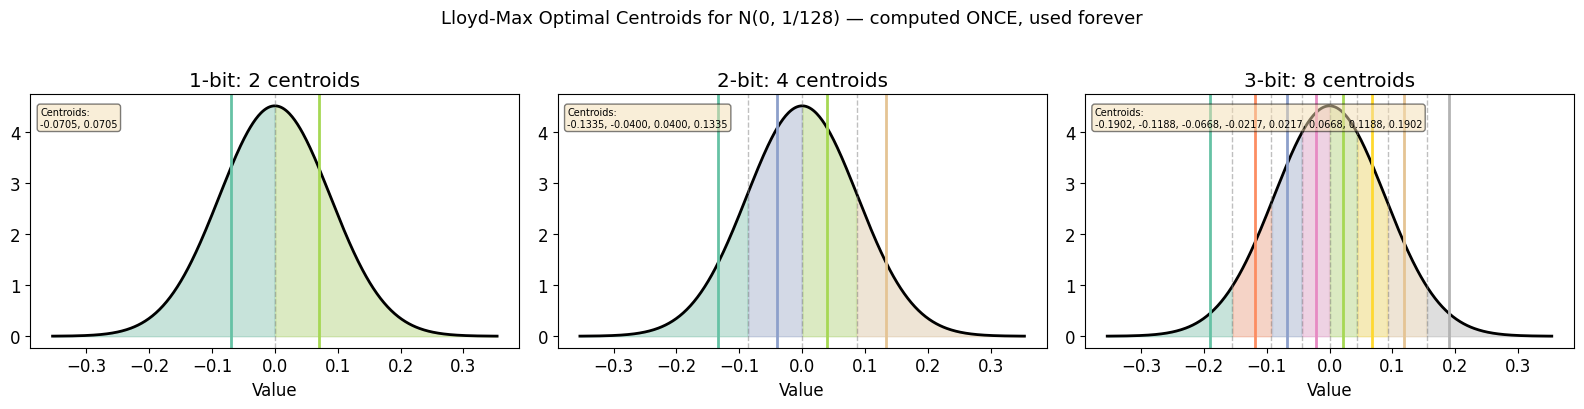

In [56]:
def lloyd_max_gaussian(n_levels, sigma, max_iter=200):
    """
    Lloyd-Max quantizer for a Gaussian distribution N(0, sigma^2).
    Returns optimal centroids and boundaries.
    """
    # Initialize centroids uniformly in [-3*sigma, 3*sigma]
    centroids = np.linspace(-3*sigma, 3*sigma, n_levels)
    
    for _ in range(max_iter):
        # Boundaries = midpoints between consecutive centroids
        boundaries = np.concatenate([[-np.inf],
                                      (centroids[:-1] + centroids[1:]) / 2,
                                      [np.inf]])
        
        # Update centroids = conditional mean in each region
        new_centroids = np.zeros_like(centroids)
        for i in range(n_levels):
            lo, hi = boundaries[i], boundaries[i+1]
            # E[X | lo < X < hi] for Gaussian
            num = sigma * (norm.pdf(lo/sigma) - norm.pdf(hi/sigma))
            den = norm.cdf(hi/sigma) - norm.cdf(lo/sigma)
            if den > 1e-15:
                new_centroids[i] = num / den
            else:
                new_centroids[i] = (lo + hi) / 2
        
        if np.allclose(centroids, new_centroids, atol=1e-12):
            break
        centroids = new_centroids
    
    return centroids, boundaries


# Compute optimal centroids for d=128 (sigma = 1/sqrt(128))
d = 128
sigma = 1 / np.sqrt(d)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
bit_widths = [1, 2, 3]

for ax, b in zip(axes, bit_widths):
    n_levels = 2**b
    centroids, boundaries = lloyd_max_gaussian(n_levels, sigma)
    
    xx = np.linspace(-4*sigma, 4*sigma, 500)
    pdf = norm.pdf(xx, 0, sigma)
    ax.plot(xx, pdf, 'k-', lw=2, label='Distribution')
    ax.fill_between(xx, pdf, alpha=0.1, color='gray')
    
    # Color each quantization region differently
    cmap = plt.cm.Set2
    for i in range(n_levels):
        lo = max(boundaries[i], xx[0])
        hi = min(boundaries[i+1], xx[-1])
        mask = (xx >= lo) & (xx <= hi)
        ax.fill_between(xx[mask], pdf[mask], alpha=0.3, color=cmap(i / n_levels))
        ax.axvline(centroids[i], color=cmap(i / n_levels), lw=2, linestyle='-')
    
    # Draw boundaries
    for bd in boundaries[1:-1]:
        ax.axvline(bd, color='gray', lw=1, linestyle='--', alpha=0.5)
    
    ax.set_title(f'{b}-bit: {n_levels} centroids')
    ax.set_xlabel('Value')
    centroids_str = ', '.join([f'{c:.4f}' for c in centroids])
    ax.text(0.02, 0.95, f'Centroids:\n{centroids_str}', transform=ax.transAxes,
            fontsize=7, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'Lloyd-Max Optimal Centroids for N(0, 1/{d}) — computed ONCE, used forever', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 5: Putting It All Together — The Full TurboQuant$_{\text{MSE}}$ Algorithm

Here's the complete algorithm in just **4 lines of math**:

### Quantize (compress)
Given vector $\mathbf{x}$ with $\|\mathbf{x}\| = 1$:

1. $\mathbf{y} = \mathbf{\Pi} \cdot \mathbf{x}$ — randomly rotate
2. For each coordinate $j$: $\text{idx}_j = \arg\min_k |y_j - c_k|$ — find nearest centroid
3. Store the indices $\text{idx}_1, \text{idx}_2, \ldots, \text{idx}_d$ (each is $b$ bits)

### Dequantize (decompress)
4. $\tilde{\mathbf{x}} = \mathbf{\Pi}^\top \cdot [c_{\text{idx}_1}, c_{\text{idx}_2}, \ldots, c_{\text{idx}_d}]$ — look up centroids, rotate back

**That's it!** Let's implement it:

In [57]:
class TurboQuantMSE:
    """Minimal TurboQuant (MSE-optimized) implementation."""
    
    def __init__(self, d, b):
        self.d = d
        self.b = b
        self.n_levels = 2**b
        
        # Step A: Generate random rotation matrix (once)
        G = np.random.randn(d, d)
        self.Pi, _ = np.linalg.qr(G)
        
        # Step B: Precompute optimal centroids (once)
        sigma = 1 / np.sqrt(d)
        self.centroids, self.boundaries = lloyd_max_gaussian(self.n_levels, sigma)
    
    def quantize(self, x):
        """Compress: vector → indices"""
        y = self.Pi @ x                              # 1. Rotate
        # 2. Find nearest centroid for each coordinate
        indices = np.searchsorted(self.boundaries[1:-1], y)  # fast bucket lookup
        return indices
    
    def dequantize(self, indices):
        """Decompress: indices → reconstructed vector"""
        y_hat = self.centroids[indices]               # 3. Look up centroids
        x_hat = self.Pi.T @ y_hat                     # 4. Rotate back
        return x_hat


# Test it!
d = 128
x = np.random.randn(d)
x = x / np.linalg.norm(x)  # normalize to unit sphere

print("Bit-width | MSE          | Compression Ratio")
print("-" * 48)
for b in [1, 2, 3, 4]:
    tq = TurboQuantMSE(d, b)
    indices = tq.quantize(x)
    x_hat = tq.dequantize(indices)
    
    mse = np.mean((x - x_hat)**2)
    ratio = 32 / b  # 32-bit float → b-bit integer
    print(f"    {b}     | {mse:.6f}     | {ratio:.0f}x")

Bit-width | MSE          | Compression Ratio
------------------------------------------------
    1     | 0.002409     | 32x
    2     | 0.001066     | 16x
    3     | 0.000273     | 11x
    4     | 0.000052     | 8x


---
## Step 6: Why Does This Work? — Distortion Bounds

TurboQuant proves that for any $b$-bit quantization:

$$\text{MSE} \leq \frac{3\pi}{2} \cdot \frac{1}{4^b}$$

And the **information-theoretic lower bound** (no algorithm can do better) is:

$$\text{MSE} \geq \frac{1}{4^b}$$

So TurboQuant is within a factor of $\frac{3\pi}{2} \approx 4.7$ of **perfect** (and in practice closer to $\approx 2.7$).

| Bits ($b$) | TurboQuant MSE | Lower Bound | Ratio |
|---|---|---|---|
| 1 | 0.36 | 0.25 | 1.45x |
| 2 | 0.117 | 0.0625 | 1.87x |
| 3 | 0.03 | 0.0156 | 1.92x |
| 4 | 0.009 | 0.0039 | 2.31x |

At 1-bit, it's only **1.45x** away from the absolute best any algorithm could ever achieve!

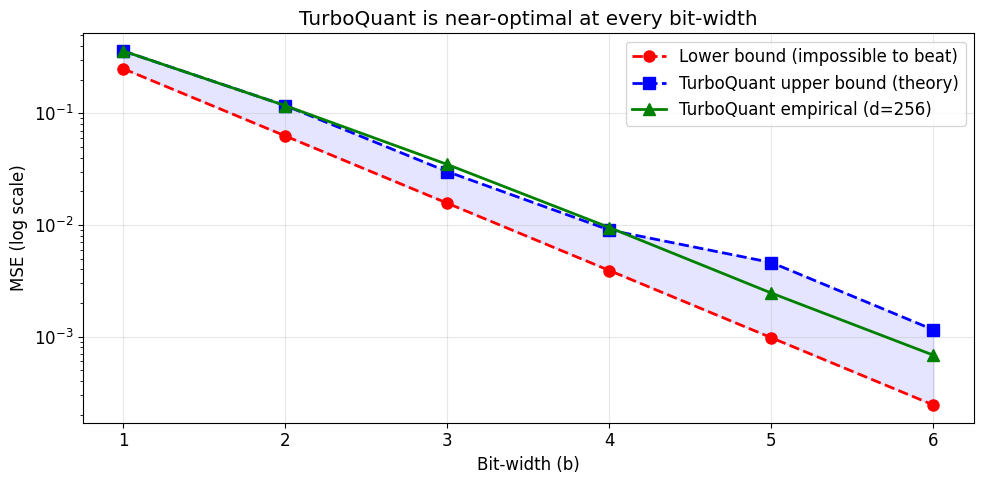

In [58]:
# Visualize: TurboQuant MSE vs theoretical bounds
bit_widths = np.arange(1, 7)
theoretical_upper = [0.36, 0.117, 0.03, 0.009, 3*np.pi/2 / 4**5, 3*np.pi/2 / 4**6]
lower_bound = 1 / 4**bit_widths

# Empirical measurement
d = 256
n_trials = 200
empirical_mse = []
for b in bit_widths:
    mses = []
    tq = TurboQuantMSE(d, int(b))
    for _ in range(n_trials):
        x = np.random.randn(d)
        x = x / np.linalg.norm(x)
        idx = tq.quantize(x)
        x_hat = tq.dequantize(idx)
        mses.append(np.sum((x - x_hat)**2))
    empirical_mse.append(np.mean(mses))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(bit_widths, lower_bound, 'r--o', lw=2, label='Lower bound (impossible to beat)', markersize=8)
ax.semilogy(bit_widths, theoretical_upper, 'b--s', lw=2, label='TurboQuant upper bound (theory)', markersize=8)
ax.semilogy(bit_widths, empirical_mse, 'g-^', lw=2, label=f'TurboQuant empirical (d={d})', markersize=8)
ax.fill_between(bit_widths, lower_bound, theoretical_upper, alpha=0.1, color='blue')
ax.set_xlabel('Bit-width (b)')
ax.set_ylabel('MSE (log scale)')
ax.set_title('TurboQuant is near-optimal at every bit-width')
ax.legend()
ax.set_xticks(bit_widths)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 7: The Inner Product Problem — Why MSE Isn't Enough

In vector databases, we don't care about reconstructing vectors perfectly.  
We care about **dot products** (similarity search):

$$\text{similarity}(\mathbf{x}, \mathbf{y}) = \langle \mathbf{x}, \mathbf{y} \rangle = \sum_i x_i \cdot y_i$$

We want: $\langle \mathbf{y}, \tilde{\mathbf{x}} \rangle \approx \langle \mathbf{y}, \mathbf{x} \rangle$

### The bias problem

MSE-optimal quantizers introduce **systematic bias** in inner product estimates!

$$\mathbb{E}[\langle \mathbf{y}, \tilde{\mathbf{x}} \rangle] \neq \langle \mathbf{y}, \mathbf{x} \rangle \quad \text{(biased!)}$$

This means dot-product estimates are consistently wrong in one direction,  
which can seriously hurt search quality.

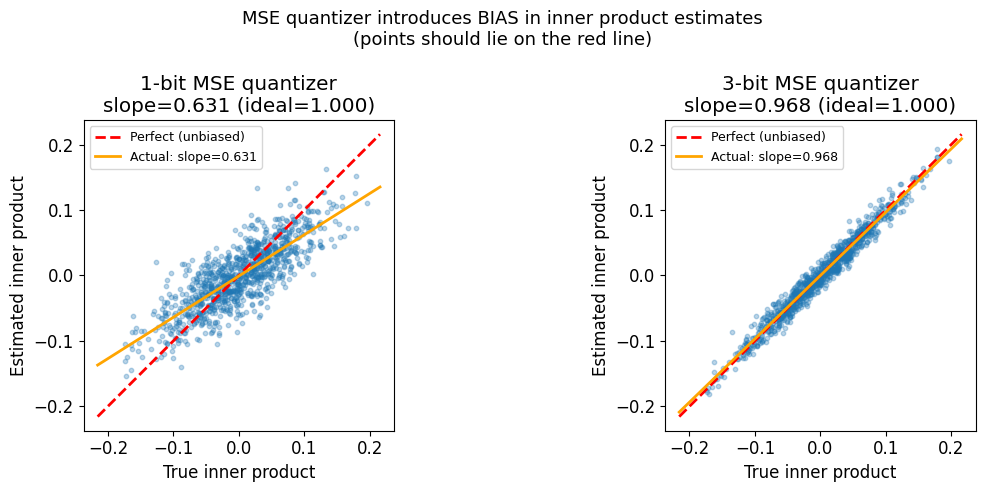

In [59]:
# Demonstrate the bias problem
d = 256
n_trials = 1000

tq_1bit = TurboQuantMSE(d, b=1)
tq_3bit = TurboQuantMSE(d, b=3)

# Fixed query vector
y = np.random.randn(d)
y = y / np.linalg.norm(y)

results_1bit = {'true_ip': [], 'est_ip': []}
results_3bit = {'true_ip': [], 'est_ip': []}

for _ in range(n_trials):
    x = np.random.randn(d)
    x = x / np.linalg.norm(x)
    true_ip = np.dot(y, x)
    
    # 1-bit MSE quantization
    x_hat_1 = tq_1bit.dequantize(tq_1bit.quantize(x))
    results_1bit['true_ip'].append(true_ip)
    results_1bit['est_ip'].append(np.dot(y, x_hat_1))
    
    # 3-bit MSE quantization
    x_hat_3 = tq_3bit.dequantize(tq_3bit.quantize(x))
    results_3bit['true_ip'].append(true_ip)
    results_3bit['est_ip'].append(np.dot(y, x_hat_3))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, res, bits in [(axes[0], results_1bit, 1), (axes[1], results_3bit, 3)]:
    ax.scatter(res['true_ip'], res['est_ip'], alpha=0.3, s=10)
    lim = max(abs(np.min(res['true_ip'])), abs(np.max(res['true_ip']))) * 1.1
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=2, label='Perfect (unbiased)')
    # Fit line to see bias
    coeffs = np.polyfit(res['true_ip'], res['est_ip'], 1)
    ax.plot([-lim, lim], [coeffs[0]*(-lim)+coeffs[1], coeffs[0]*lim+coeffs[1]], 
            'orange', lw=2, label=f'Actual: slope={coeffs[0]:.3f}')
    ax.set_xlabel('True inner product')
    ax.set_ylabel('Estimated inner product')
    ax.set_title(f'{bits}-bit MSE quantizer\nslope={coeffs[0]:.3f} (ideal=1.000)')
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('MSE quantizer introduces BIAS in inner product estimates\n(points should lie on the red line)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 8: The Fix — Two-Stage Inner Product TurboQuant

TurboQuant's solution is elegant: a **two-stage** approach.

### Stage 1: MSE Quantization (b-1 bits)
Apply TurboQuant$_{\text{MSE}}$ with bit-width $b-1$ to get $\tilde{\mathbf{x}}_{\text{mse}}$.  
Compute the **residual** (the error):

$$\mathbf{r} = \mathbf{x} - \tilde{\mathbf{x}}_{\text{mse}}$$

### Stage 2: QJL on the residual (1 bit)
Apply a **1-bit** Quantized Johnson-Lindenstrauss (QJL) transform to the residual:

$$\text{qjl} = \text{sign}(\mathbf{S} \cdot \mathbf{r})$$

where $\mathbf{S}$ is a random Gaussian matrix. This gives an **unbiased** estimate of the residual's inner products.

### Dequantization

$$\tilde{\mathbf{x}} = \tilde{\mathbf{x}}_{\text{mse}} + \|\mathbf{r}\| \cdot \frac{\sqrt{\pi/2}}{d} \cdot \mathbf{S}^\top \cdot \text{qjl}$$

### Why this works

- Stage 1 makes the residual $\mathbf{r}$ **small** (low MSE)
- Stage 2 gives an **unbiased** correction for the remaining error
- Total: $b-1 + 1 = b$ bits, **unbiased** inner product estimates

$$\mathbb{E}[\langle \mathbf{y}, \tilde{\mathbf{x}} \rangle] = \langle \mathbf{y}, \mathbf{x} \rangle \quad \checkmark$$

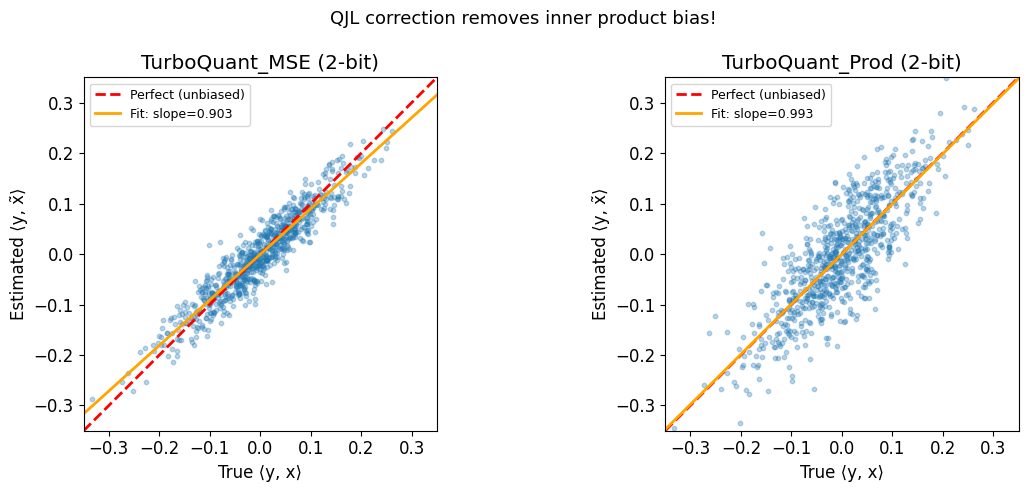

In [60]:
class TurboQuantMSE:
    """Minimal TurboQuant (MSE-optimized) implementation."""
    
    def __init__(self, d, b):
        self.d = d
        self.b = b
        self.n_levels = 2**b
        
        # Step A: Generate random rotation matrix (once)
        G = np.random.randn(d, d)
        self.Pi, _ = np.linalg.qr(G)
        
        # Step B: Precompute optimal centroids (once)
        sigma = 1 / np.sqrt(d)
        self.centroids, self.boundaries = lloyd_max_gaussian(self.n_levels, sigma)
    
    def quantize(self, x):
        """Compress: vector → indices"""
        y = self.Pi @ x                              # 1. Rotate
        # 2. Find nearest centroid for each coordinate
        indices = np.searchsorted(self.boundaries[1:-1], y)  # fast bucket lookup
        return indices
    
    def dequantize(self, indices):
        """Decompress: indices → reconstructed vector"""
        y_hat = self.centroids[indices]               # 3. Look up centroids
        x_hat = self.Pi.T @ y_hat                     # 4. Rotate back
        return x_hat


class TurboQuantProd:
    """TurboQuant optimized for unbiased inner products."""
    
    def __init__(self, d, b):
        self.d = d
        self.b = b
        
        # Stage 1: MSE quantizer with (b-1) bits
        self.mse_quant = TurboQuantMSE(d, b - 1)
        
        # Stage 2: Random projection matrix for QJL
        self.S = np.random.randn(d, d)
    
    def quantize(self, x):
        # Stage 1: MSE quantize with (b-1) bits
        mse_indices = self.mse_quant.quantize(x)
        x_mse = self.mse_quant.dequantize(mse_indices)
        
        # Residual
        r = x - x_mse
        gamma = np.linalg.norm(r)
        
        # Stage 2: QJL (1-bit quantization of residual)
        qjl = np.sign(self.S @ r)  # 1 bit per coordinate
        
        return mse_indices, qjl, gamma
    
    def dequantize(self, mse_indices, qjl, gamma):
        # Reconstruct MSE part
        x_mse = self.mse_quant.dequantize(mse_indices)
        
        # Reconstruct QJL correction
        x_qjl = gamma * np.sqrt(np.pi / 2) / self.d * (self.S.T @ qjl)
        
        return x_mse + x_qjl


# Compare bias: MSE-only vs Inner-Product TurboQuant
d = 128
b = 2
n_trials = 800

tq_mse = TurboQuantMSE(d, b)
tq_prod = TurboQuantProd(d, b)

y = np.random.randn(d)
y = y / np.linalg.norm(y)

mse_ips = {'true': [], 'est': []}
prod_ips = {'true': [], 'est': []}

for _ in range(n_trials):
    x = np.random.randn(d)
    x = x / np.linalg.norm(x)
    true_ip = np.dot(y, x)
    
    # MSE-only
    x_hat_mse = tq_mse.dequantize(tq_mse.quantize(x))
    mse_ips['true'].append(true_ip)
    mse_ips['est'].append(np.dot(y, x_hat_mse))
    
    # Inner-product TurboQuant
    idx, qjl, gamma = tq_prod.quantize(x)
    x_hat_prod = tq_prod.dequantize(idx, qjl, gamma)
    prod_ips['true'].append(true_ip)
    prod_ips['est'].append(np.dot(y, x_hat_prod))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, res, title in [(axes[0], mse_ips, f'TurboQuant_MSE ({b}-bit)'),
                        (axes[1], prod_ips, f'TurboQuant_Prod ({b}-bit)')]:
    ax.scatter(res['true'], res['est'], alpha=0.3, s=10)
    lim = 0.35
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=2, label='Perfect (unbiased)')
    coeffs = np.polyfit(res['true'], res['est'], 1)
    ax.plot([-lim, lim], [coeffs[0]*(-lim)+coeffs[1], coeffs[0]*lim+coeffs[1]],
            'orange', lw=2, label=f'Fit: slope={coeffs[0]:.3f}')
    ax.set_xlabel('True ⟨y, x⟩')
    ax.set_ylabel('Estimated ⟨y, x̃⟩')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect('equal')

plt.suptitle('QJL correction removes inner product bias!', fontsize=13)
plt.tight_layout()
plt.show()

---
## Step 9: End-to-End Demo — Vector Search

Let's simulate a real use case: **nearest neighbor search** with quantized vectors.

1. Build a "database" of random vectors
2. Quantize them with TurboQuant
3. Given a query, find the most similar vector using quantized dot products
4. Compare with the true answer

In [61]:
# Nearest neighbor search demo
d = 128
n_vectors = 5000
n_queries = 50

# Create database vectors (normalized)
database = np.random.randn(n_vectors, d)
database = database / np.linalg.norm(database, axis=1, keepdims=True)

# Create query vectors
queries = np.random.randn(n_queries, d)
queries = queries / np.linalg.norm(queries, axis=1, keepdims=True)

def recall_at_k(true_top, predicted_top, k):
    """How often is the true #1 result in the predicted top-k?"""
    hits = sum(1 for t, p in zip(true_top, predicted_top) if t in p[:k])
    return hits / len(true_top)

print(f"Database: {n_vectors} vectors, dim={d}")
print(f"Queries:  {n_queries}")
print()

# True nearest neighbors (brute force)
true_scores = queries @ database.T
true_top1 = np.argmax(true_scores, axis=1)

print(f"{'Method':<25} {'Recall@1':>10} {'Recall@5':>10} {'Recall@10':>10}  {'Bits':>5}  {'Compression':>12}")
print("-" * 80)

for b in [1, 2, 3, 4]:
    tq = TurboQuantProd(d, b)
    
    # Quantize entire database3
    quantized_db = np.zeros((n_vectors, d))
    for i in range(n_vectors):
        idx, qjl, gamma = tq.quantize(database[i])
        quantized_db[i] = tq.dequantize(idx, qjl, gamma)
    
    # Search with quantized vectors
    quant_scores = queries @ quantized_db.T
    quant_rankings = np.argsort(-quant_scores, axis=1)
    
    r1 = recall_at_k(true_top1, quant_rankings, 1)
    r5 = recall_at_k(true_top1, quant_rankings, 5)
    r10 = recall_at_k(true_top1, quant_rankings, 10)
    
    print(f"TurboQuant_prod {b}-bit   {r1:>10.1%} {r5:>10.1%} {r10:>10.1%}  {b:>5}  {32/b:>10.0f}x")

Database: 5000 vectors, dim=128
Queries:  50

Method                      Recall@1   Recall@5  Recall@10   Bits   Compression
--------------------------------------------------------------------------------
TurboQuant_prod 1-bit         6.0%      14.0%      18.0%      1          32x
TurboQuant_prod 2-bit        16.0%      38.0%      52.0%      2          16x
TurboQuant_prod 3-bit        34.0%      76.0%      94.0%      3          11x
TurboQuant_prod 4-bit        70.0%      98.0%     100.0%      4           8x


---
## Summary: The Entire Algorithm on One Page

```
┌─────────────────────────────────────────────────────┐
│                    SETUP (once)                      │
│  1. Generate random rotation matrix Π               │
│  2. Compute optimal centroids via Lloyd-Max          │
│  3. Generate random matrix S for QJL                 │
└─────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────┐
│              QUANTIZE (per vector)                   │
│  1. y = Π · x            (rotate)                   │
│  2. idx = nearest(y, centroids)  (b-1 bit indices)  │
│  3. x̃_mse = Πᵀ · centroids[idx] (MSE reconstruct) │
│  4. r = x - x̃_mse       (residual)                 │
│  5. qjl = sign(S · r)    (1-bit QJL)               │
│  6. Store: idx, qjl, ‖r‖  → total b bits/coord     │
└─────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────┐
│             DEQUANTIZE (per vector)                  │
│  x̃ = x̃_mse + ‖r‖·√(π/2)/d · Sᵀ · qjl             │
└─────────────────────────────────────────────────────┘
```

### Why it's special:
- **No training**: Works immediately on any data (data-oblivious)
- **Near-optimal**: Within ~2.7x of the information-theoretic best
- **Unbiased**: Inner product estimates are unbiased (crucial for search)
- **Embarrassingly parallel**: Every coordinate is independent → GPU-friendly
- **Fast**: Just matrix multiply + table lookup (no iterative search)